# GeoWatch — Phase 2: NDVI & NBR Spectral Index Engine

This notebook demonstrates the deterministic spectral-index functions built in
`src/remote_sensing/` (Milestone 1 of the GeoWatch roadmap):

- `compute_ndvi()` — vegetation health
- `compute_nbr()` — burn ratio
- `compute_dnbr()` — pre/post-fire change

These functions are unit-tested independently in `tests/test_ndvi.py`,
`tests/test_nbr.py`, and `tests/test_spectral.py`. This notebook exists to
show the *behavior* visually, not to re-derive correctness — that's what
the test suite is for.

Since GeoWatch doesn't yet have a live imagery provider wired in (that's
Milestone 3), this notebook uses a **synthetic scene**: a small array
constructed to contain a clearly "healthy vegetation" region and a clearly
"burned" region, so the index values are interpretable by construction.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from src.remote_sensing.ndvi import compute_ndvi
from src.remote_sensing.nbr import compute_nbr, compute_dnbr


## 1. Build a synthetic pre-fire / post-fire scene

We construct three bands (RED, NIR, SWIR) for two time points. The left half
of the scene stays healthy vegetation in both scenes; the right half is
healthy pre-fire and burned post-fire.

Reflectance values are illustrative, chosen to sit in realistic ranges for
each land cover type — not derived from a specific real sensor.

In [2]:
SIZE = 64

def band(healthy_value, burned_value, noise=0.01, seed=0):
    rng = np.random.default_rng(seed)
    arr = np.full((SIZE, SIZE), healthy_value, dtype=np.float64)
    arr[:, SIZE // 2:] = burned_value
    arr += rng.normal(0, noise, size=arr.shape)
    return np.clip(arr, 0, 1)

# Pre-fire: entire scene is healthy vegetation.
red_pre  = band(healthy_value=0.08, burned_value=0.08, seed=1)
nir_pre  = band(healthy_value=0.50, burned_value=0.50, seed=2)
swir_pre = band(healthy_value=0.15, burned_value=0.15, seed=3)

# Post-fire: left half unchanged, right half now reads as burned.
red_post  = band(healthy_value=0.08, burned_value=0.20, seed=4)
nir_post  = band(healthy_value=0.50, burned_value=0.12, seed=5)
swir_post = band(healthy_value=0.15, burned_value=0.32, seed=6)

print("Band shapes:", red_pre.shape)


Band shapes: (64, 64)


## 2. Compute NDVI (pre- and post-fire)

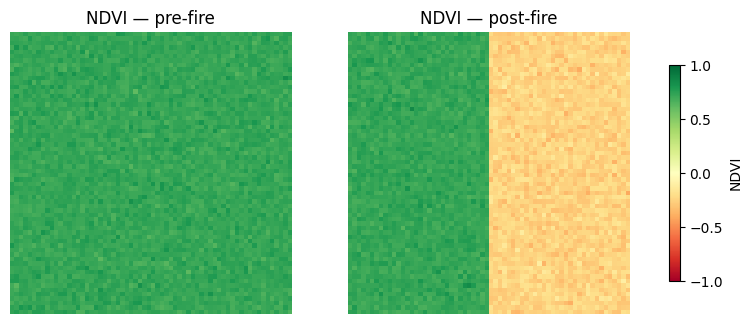

Mean NDVI pre-fire (right half):  0.724
Mean NDVI post-fire (right half): -0.249


In [3]:
ndvi_pre  = compute_ndvi(nir_pre, red_pre)
ndvi_post = compute_ndvi(nir_post, red_post)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(ndvi_pre, cmap="RdYlGn", vmin=-1, vmax=1)
axes[0].set_title("NDVI — pre-fire")
axes[0].axis("off")
im1 = axes[1].imshow(ndvi_post, cmap="RdYlGn", vmin=-1, vmax=1)
axes[1].set_title("NDVI — post-fire")
axes[1].axis("off")
fig.colorbar(im1, ax=axes, shrink=0.7, label="NDVI")
plt.show()

print(f"Mean NDVI pre-fire (right half):  {ndvi_pre[:, SIZE//2:].mean():.3f}")
print(f"Mean NDVI post-fire (right half): {ndvi_post[:, SIZE//2:].mean():.3f}")


## 3. Compute NBR and dNBR

dNBR is the primary burned-area change signal. A high positive dNBR in the
right half (post-fire region) is exactly what we constructed the synthetic
scene to produce — this is a sanity check on the pipeline, not a scientific
claim about any real location.

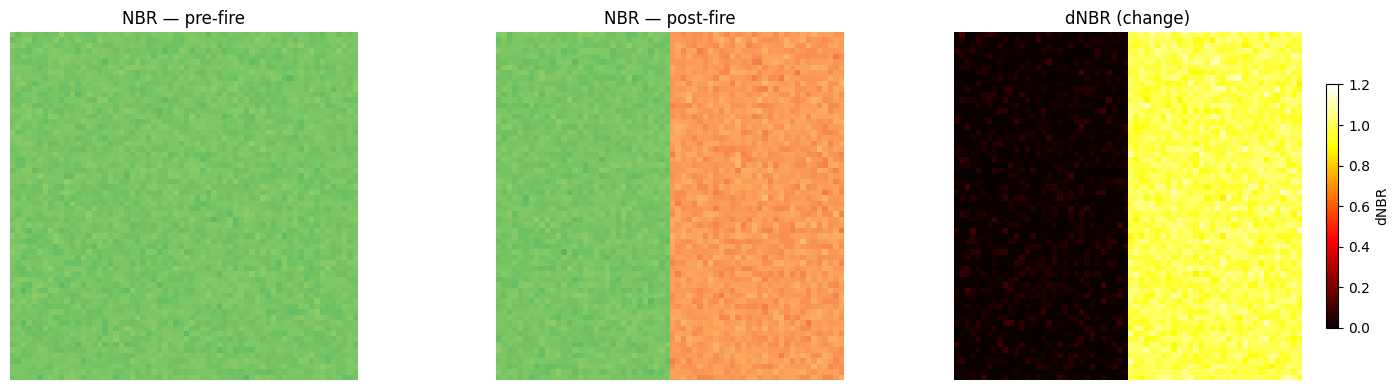

Mean dNBR, unchanged (left) half: 0.001
Mean dNBR, burned (right) half:   0.992


In [4]:
nbr_pre  = compute_nbr(nir_pre, swir_pre)
nbr_post = compute_nbr(nir_post, swir_post)
dnbr     = compute_dnbr(nbr_pre, nbr_post)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(nbr_pre, cmap="RdYlGn", vmin=-1, vmax=1)
axes[0].set_title("NBR — pre-fire")
axes[0].axis("off")
axes[1].imshow(nbr_post, cmap="RdYlGn", vmin=-1, vmax=1)
axes[1].set_title("NBR — post-fire")
axes[1].axis("off")
im2 = axes[2].imshow(dnbr, cmap="hot", vmin=0, vmax=1.2)
axes[2].set_title("dNBR (change)")
axes[2].axis("off")
fig.colorbar(im2, ax=axes[2], shrink=0.7, label="dNBR")
plt.tight_layout()
plt.show()

print(f"Mean dNBR, unchanged (left) half: {dnbr[:, :SIZE//2].mean():.3f}")
print(f"Mean dNBR, burned (right) half:   {dnbr[:, SIZE//2:].mean():.3f}")


## 4. No-data handling

The functions never produce `inf` or a misleading `0` for degenerate pixels
— division by zero and NaN inputs both propagate to NaN, which is the
correct way to represent "no information," rather than a computed value.

In [5]:
edge_case_nir = np.array([0.0, np.nan, 0.5])
edge_case_red = np.array([0.0, 0.1,    0.1])

result = compute_ndvi(edge_case_nir, edge_case_red)
print("NIR:   ", edge_case_nir)
print("RED:   ", edge_case_red)
print("NDVI:  ", result)
print()
print("Pixel 0 (0/0, no signal):     NaN as expected ->", np.isnan(result[0]))
print("Pixel 1 (NaN input):          NaN as expected ->", np.isnan(result[1]))
print("Pixel 2 (valid healthy veg):  computed normally ->", round(result[2], 4))


NIR:    [0.  nan 0.5]
RED:    [0.  0.1 0.1]
NDVI:   [       nan        nan 0.66666667]

Pixel 0 (0/0, no signal):     NaN as expected -> True
Pixel 1 (NaN input):          NaN as expected -> True
Pixel 2 (valid healthy veg):  computed normally -> 0.6667


## Next: Milestone 2

This notebook only proves the spectral math on a synthetic scene. Milestone 2
applies `compute_dnbr()` to real pre/post-fire sample imagery, adds
configurable burn-severity thresholds, burned-area masking, and affected-area
statistics — the first real GeoWatch wildfire-detection use case.